In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
import numpy as np
import pastas as ps
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 2
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 2/2 [00:07<00:00,  3.56s/it]


In [4]:
gw = oc.obs["GMW000000046935001"]
print(gw)

GroundwaterObs GMW000000046935001
-----metadata------
name : GMW000000046935001 
x : 96982.07766291886 
y : 441656.1976649185 
location : 133572-26 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -6.83 
screen_bottom : -7.83 
ground_level : -5.63 
tube_top : -5.73 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2021-04-08 23:00:00  -6.43     2  Gemeten   hand
2021-05-11 23:00:00  -6.39     2  Gemeten   hand
2021-06-09 23:00:00  -6.56     2  Gemeten   hand
2021-07-15 23:00:00  -6.62     2  Gemeten   hand
2021-08-09 23:00:00  -6.56     2  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-15 09:06:53  -6.42     2           diver
2026-03-15 13:06:55  -6.42     2           diver
2026-03-15 17:06:56  -6.41     2           diver
2026-03-15 21:06:58  -6.41     2           diver
2026-03-16 01:06:59  -6.38     2           diver

[2207 rows x 4 columns

Counts per origin:
 origin
diver    1769
hand       27
Name: value, dtype: int64
Primary origin chosen: diver
Daily series points: 329


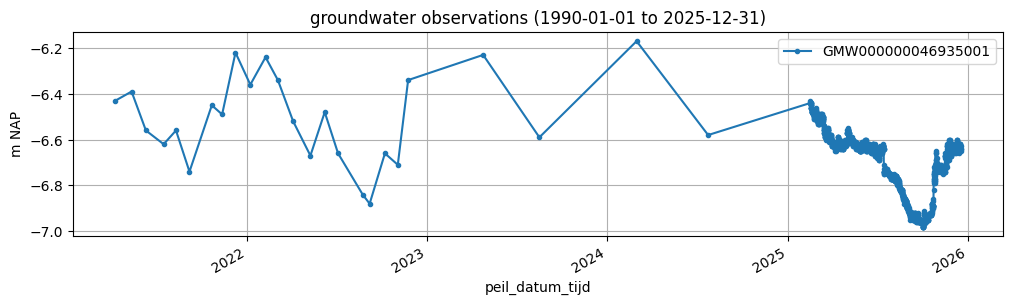

In [5]:
# Gebruik centrale tijdconfiguratie
tmin = START_DATE
tmax = END_DATE

def build_daily_gw_fill(
    gw_df: pd.DataFrame,
    tmin=None,
    tmax=None,
    primary_rule="most_obs",                 # "most_obs"
    fill_priority=("hand", "diver_validated", "diver"),
    within_day="last",                       # "last" or "median"
):
    df = gw_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.dropna(subset=["value", "origin"]).sort_index()

    # filter op periode
    if tmin is not None:
        df = df.loc[df.index >= pd.to_datetime(tmin)]
    if tmax is not None:
        df = df.loc[df.index <= pd.to_datetime(tmax)]

    # dagkolom
    df["date"] = df.index.floor("D")

    # helper: maak daily series voor 1 origin
    def daily_for_origin(origin):
        dfo = df[df["origin"] == origin].copy()
        if dfo.empty:
            return pd.Series(dtype="float64"), pd.Series(dtype="object")

        if within_day == "last":
            dfo = dfo.groupby("date").tail(1)
            s = dfo.set_index("date")["value"].sort_index()
        elif within_day == "median":
            s = dfo.groupby("date")["value"].median().sort_index()
        else:
            raise ValueError("within_day must be 'last' or 'median'")

        used = pd.Series(origin, index=s.index, name="origin_used")
        return s, used

    # 1) bepaal primary origin (meeste metingen)
    counts = df.groupby("origin")["value"].count().sort_values(ascending=False)
    if counts.empty:
        raise ValueError("Geen data in gw_df na filtering.")

    primary_origin = counts.index[0]
    primary_series, origin_used = daily_for_origin(primary_origin)

    # 2) aanvullen met andere origins
    combined = primary_series.copy()
    fill_list = [o for o in fill_priority if o != primary_origin]

    for o in fill_list:
        s_o, used_o = daily_for_origin(o)
        if s_o.empty:
            continue

        union_idx = combined.index.union(s_o.index)
        combined = combined.reindex(union_idx)
        origin_used = origin_used.reindex(union_idx)

        mask = combined.isna()
        combined.loc[mask] = s_o.reindex(union_idx).loc[mask]
        origin_used.loc[mask] = used_o.reindex(union_idx).loc[mask]

    combined.name = "gw_daily"

    return combined.sort_index(), origin_used.sort_index(), primary_origin, counts


# ---- gebruik ----
gw_daily, gw_origin_used, primary_origin, counts = build_daily_gw_fill(
    gw,
    tmin=tmin,
    tmax=tmax,
    fill_priority=("hand", "diver_validated", "diver"),
    within_day="last",
)

print("Counts per origin:\n", counts)
print("Primary origin chosen:", primary_origin)
print("Daily series points:", gw_daily.notna().sum())

# ---- ruwe groundwater plot ook op hetzelfde tijdvenster ----
gw_plot = gw.copy()
gw_plot.index = pd.to_datetime(gw_plot.index)
gw_plot = gw_plot.loc[(gw_plot.index >= tmin) & (gw_plot.index <= tmax)]

ax = gw_plot["value"].plot(
    figsize=(12, 3),
    marker=".",
    grid=True,
    label=getattr(gw, "name", "gw"),
    legend=True,
    ylabel="m NAP",
    title=f"groundwater observations ({tmin} to {tmax})",
)

INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (96982.07766291886, 441656.1976649185) and meteovariable RH
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (96982.07766291886, 441656.1976649185) and meteovariable EV24
  return ax.plot(*args, **kwds)

Aantal neerslag-observaties: 13149
Aantal verdamping-observaties: 13149


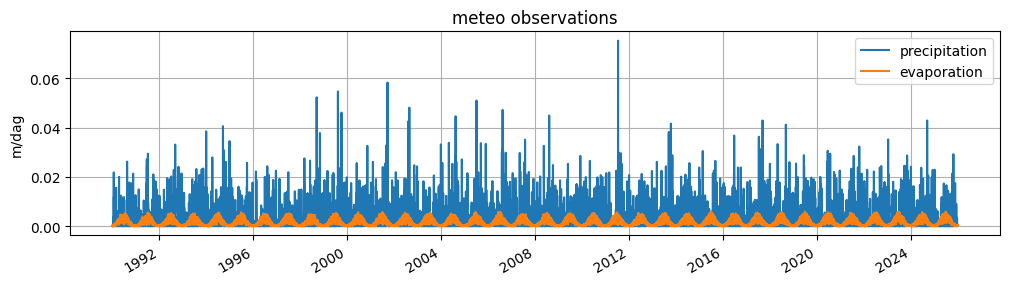

In [6]:
precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)

# --- Plot as spikes (like rainfall graphs) ---
fig, ax = plt.subplots(figsize=(12, 3))

# precipitation as vertical lines
ax.vlines(
    precipitation.index,
    ymin=0,
    ymax=precipitation["RH"],
    linewidth=0.6,
    label="precipitation",
)

ax = precipitation["RH"].plot(label="precipitation", legend=True, figsize=(12, 3))
evaporation["EV24"].plot(
    ax=ax,
    label="evaporation",
    legend=True,
    grid=True,
    ylabel="m/dag",
    title="meteo observations",
)

# Print het aantal observaties voor neerslag en verdamping
print(f"Aantal neerslag-observaties: {precipitation.shape[0]}")
print(f"Aantal verdamping-observaties: {evaporation.shape[0]}")

Fit report GMW000000046935001 (prim Fit Statistics
nfev     49                     EVP          74.26
nobs     329                    R2            0.74
noise    False                  RMSE          0.08
tmin     2021-04-08 00:00:00    AICc      -1689.56
tmax     2025-12-17 00:00:00    BIC       -1670.77
freq     D                      Obj           0.94
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No
solver   LeastSquares           weights        Yes

Parameters (5 optimized)
               optimal     initial  vary
rainevap_A  235.476210  188.958003  True
rainevap_n    1.043199    1.000000  True
rainevap_a  189.150773   10.000000  True
rainevap_f   -0.804965   -1.000000  True
constant_d   -6.803121   -6.683465  True
INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals with gap larger than 50.0 days
INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals w

[<Axes: xlabel='date', ylabel='Head'>,
 <Axes: >,
 <Axes: title={'right': "Stresses: ['RH', 'EV24']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}>,
 <Axes: title={'left': 'Model parameters ($n_c$=5)'}>]

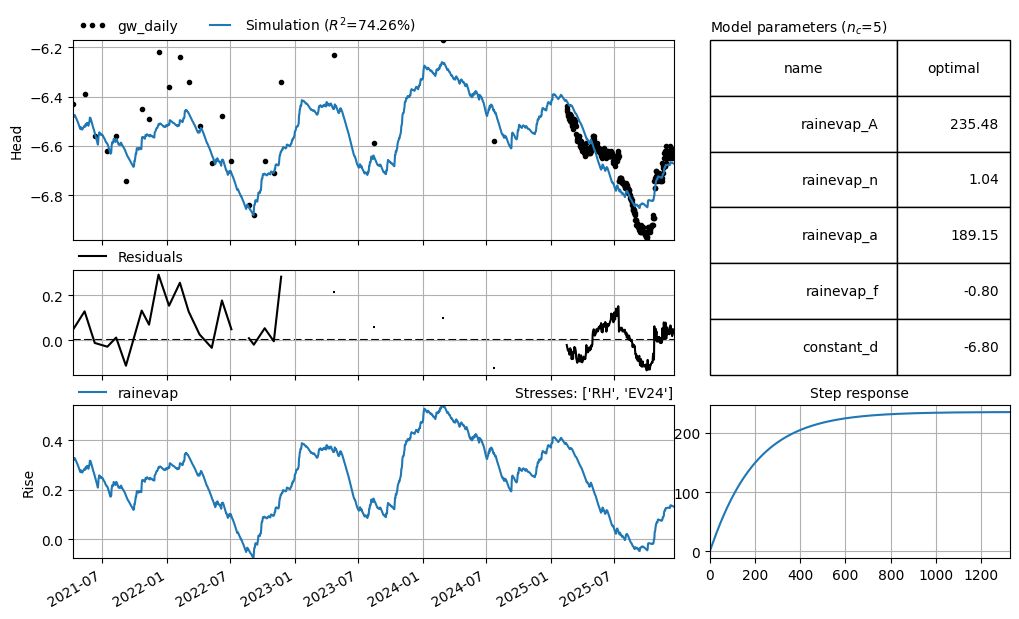

In [7]:
# Create a Pastas Model
ml = ps.Model(gw_daily, name=f"{gw.name} (primary={primary_origin})")

# Add the recharge data as explanatory variable
ts1 = ps.RechargeModel(
    precipitation["RH"].resample("D").sum(),   # dagtotaal
    evaporation["EV24"].resample("D").sum(),   # dagtotaal
    ps.Gamma(),
    name="rainevap",
    settings=("prec", "evap"),
)

# Add the stressmodel to the model and solve for period after 2015
ml.add_stressmodel(ts1)
ml.solve(tmin=START_DATE, tmax=END_DATE)
ml.plots.results(figsize=(10, 6))

INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals with gap larger than 50.0 days
INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals with gap larger than 50.0 days
INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals with gap larger than 50.0 days
INFO:pastas.plotting.plotutil.plot_series_with_gaps:Isolated point found in series Residuals with gap larger than 50.0 days


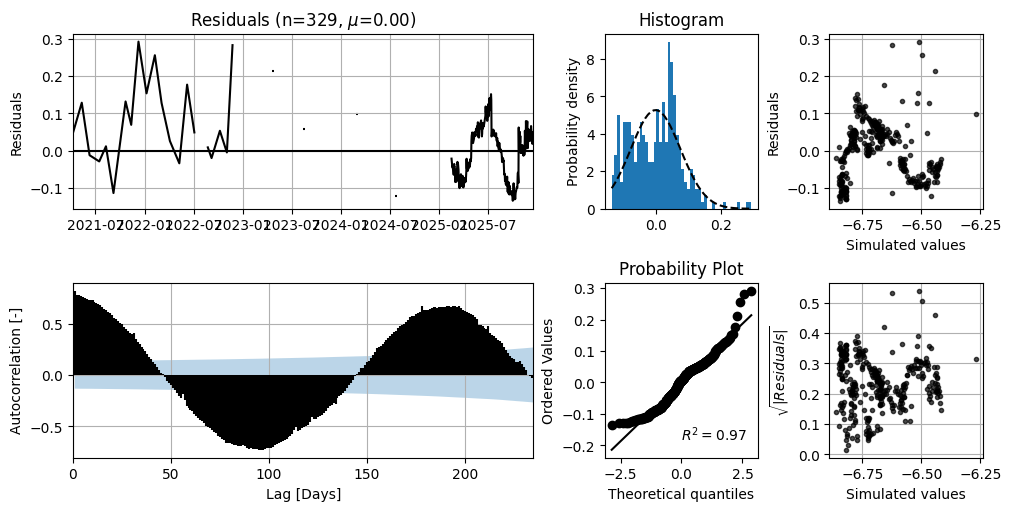

In [8]:
axes = ml.plots.diagnostics()

Locatie: x=96982.08, y=441656.20 | Periode: 1990-01-01 tot 2025-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (96982.07766291886, 441656.1976649185) and meteovariable RH
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (96982.07766291886, 441656.1976649185) and meteovariable EV24
Precip punten: 13149 | van 1990-01-01 01:00:00 tot 2025-12-31 01:00:00
Evap punten:   13149 | van 1990-01-01 01:00:00 tot 2025-12-31 01:00:00
Verdampingsfactor: -1.000


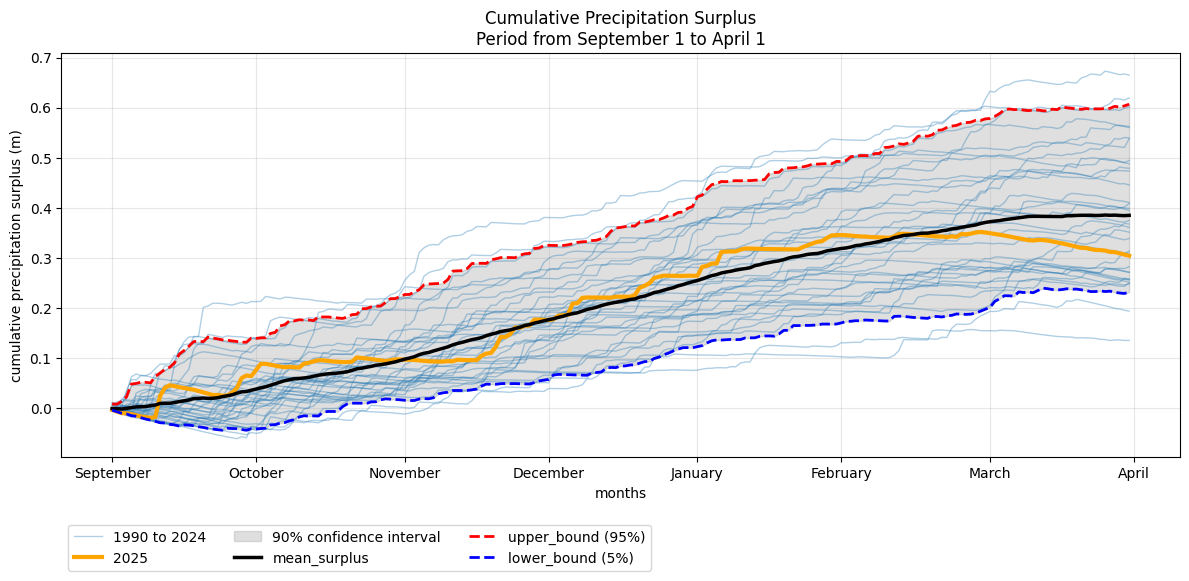

Aantal seizoenen in plot: 35 (max 2024-2025)


In [9]:
# ────────────────────────────────────────────────
# Config
# ────────────────────────────────────────────────
start_date = "1990-01-01"
end_date   = "2025-12-31"           # veilig: seizoen 2024-2025 eindigt apr 2025

# Coördinaten ophalen
try:
    gw_location = oc.obs["GMW000000046935001"]  # ← pas GW-code aan!
    x_loc = gw_location.x
    y_loc = gw_location.y
except:
    x_loc, y_loc = gw_x, gw_y  # fallback

print(f"Locatie: x={x_loc:.2f}, y={y_loc:.2f} | Periode: {start_date} tot {end_date}")

# ────────────────────────────────────────────────
# Laad KNMI data (xy-methode + fill voor robuustheid)
# ────────────────────────────────────────────────
precip_all = hpd.PrecipitationObs.from_knmi(
    xy=(x_loc, y_loc),
    start=start_date,
    end=end_date,
    fill_missing_obs=True,
 )

evap_all = hpd.EvaporationObs.from_knmi(
    xy=(x_loc, y_loc),
    meteo_var="EV24",
    start=start_date,
    end=end_date,
    fill_missing_obs=True,
 )

# Extract Series (veilige manier)
if hasattr(precip_all, 'columns'):
    value_col_p = [col for col in precip_all.columns if col not in ['x', 'y', 'station', 'meta']]
    p_series = precip_all[value_col_p[0]] if value_col_p else pd.Series()
else:
    p_series = pd.Series()

if hasattr(evap_all, 'columns'):
    value_col_e = [col for col in evap_all.columns if col not in ['x', 'y', 'station', 'meta']]
    e_series = evap_all[value_col_e[0]] if value_col_e else pd.Series()
else:
    e_series = pd.Series()

print(f"Precip punten: {len(p_series)} | van {p_series.index.min()} tot {p_series.index.max()}")
print(f"Evap punten:   {len(e_series)} | van {e_series.index.min()} tot {e_series.index.max()}")

# ────────────────────────────────────────────────
# Verdampingsfactor
# ────────────────────────────────────────────────
evap_factor = -1.0
if 'ml' in globals() and hasattr(ml, 'parameters'):
    for param in ["gwa_f", "f", "constant"]:
        if param in ml.parameters.index:
            evap_factor = ml.parameters.loc[param, "optimal"]
            break
print(f"Verdampingsfactor: {evap_factor:.3f}")

# ────────────────────────────────────────────────
# Surplus berekenen – MAX tot seizoen 2024-2025
# ────────────────────────────────────────────────
surplus = pd.DataFrame()
plt.figure(figsize=(12, 6))

min_year = max(p_series.index.year.min(), e_series.index.year.min(), 1990) if not p_series.empty and not e_series.empty else 1990
max_year = 2024   # ← FORCEREN: laatste volledige seizoen = 2024 (sep 2024 – apr 2025)

for year in range(min_year, max_year + 1):
    period_start = f"{year}-09-01"
    period_end   = f"{year+1}-04-01"
    
    p_year = p_series[period_start:period_end]
    e_year = e_series[period_start:period_end]
    
    common_idx = p_year.index.intersection(e_year.index)
    if len(common_idx) < 150:
        print(f"Jaar {year}: te weinig data ({len(common_idx)} dagen) → overgeslagen")
        continue
    
    y = p_year.loc[common_idx] + evap_factor * e_year.loc[common_idx]
    y = y.cumsum()
    # Verwijder schrikkeldag indien aanwezig
    y = y[~((y.index.month == 2) & (y.index.day == 29))]
    x = np.arange(len(y))
    
    # Kleur: oranje en dikker voor laatste jaar (2024-2025)
    if year == max_year:
        color = "orange"
        lw = 3.0
        alpha = 1.0
        label = "2025"   # label zoals in je afbeelding
    else:
        color = "C0"
        lw = 1.0
        alpha = 0.35
        label = None if year > min_year else f"{min_year} to {max_year}"
    
    plt.plot(x, y, color=color, lw=lw, alpha=alpha, label=label)
    
    # Opslaan voor stats (zonder jaar 2025/2026)
    y.index = y.index.strftime("%m-%d")
    surplus[year] = y

# Schrikkeldag verwijderen uit alle reeksen
surplus = surplus[~surplus.index.str.contains("02-29", na=False)]

# Percentielen + gemiddelde
if not surplus.empty:
    upper_bound = surplus.quantile(0.95, axis=1)
    lower_bound = surplus.quantile(0.05, axis=1)
    mean_surplus = surplus.mean(axis=1)
    # Remove leap day if present
    upper_bound = upper_bound.drop(index="2-29", errors="ignore")
    lower_bound = lower_bound.drop(index="2-29", errors="ignore")
    mean_surplus = mean_surplus.drop(index="2-29", errors="ignore")
    n = len(mean_surplus)
    x_vals = np.arange(n)
    plt.fill_between(x_vals, lower_bound, upper_bound, color="gray", alpha=0.25, label="90% confidence interval")
    # Highlight mean_surplus, upper_bound, lower_bound
    plt.plot(x_vals, mean_surplus, color="black", lw=2.5, label="mean_surplus", zorder=10)
    plt.plot(x_vals, upper_bound, color="red", lw=2, linestyle="--", label="upper_bound (95%)", zorder=10)
    plt.plot(x_vals, lower_bound, color="blue", lw=2, linestyle="--", label="lower_bound (5%)", zorder=10)
# Opmaak zoals in je afbeelding
plt.xlabel("months")
plt.ylabel("cumulative precipitation surplus (m)")
plt.title("Cumulative Precipitation Surplus\nPeriod from September 1 to April 1")
plt.xticks(
    [0, 30, 61, 91, 122, 152, 183, 213],
    ["September", "October", "November", "December", "January", "February", "March", "April"]
)
plt.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.15))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Aantal seizoenen in plot: {len(surplus.columns)} (max 2024-2025)")

INFO:pastas.timeseries._fill_after:Time Series 'None' was extended in the future to 2026-04-01 00:00:00 with the mean value (0.00071) of the time series.
INFO:pastas.timeseries._fill_after:Time Series 'None' was extended in the future to 2026-04-01 00:00:00 with the mean value (0.00075) of the time series.
INFO:pastas.timeseries._fill_after:Time Series 'None' was extended in the future to 2026-04-01 00:00:00 with the mean value (0.00068) of the time series.
  return ax.plot(*args, **kwds)



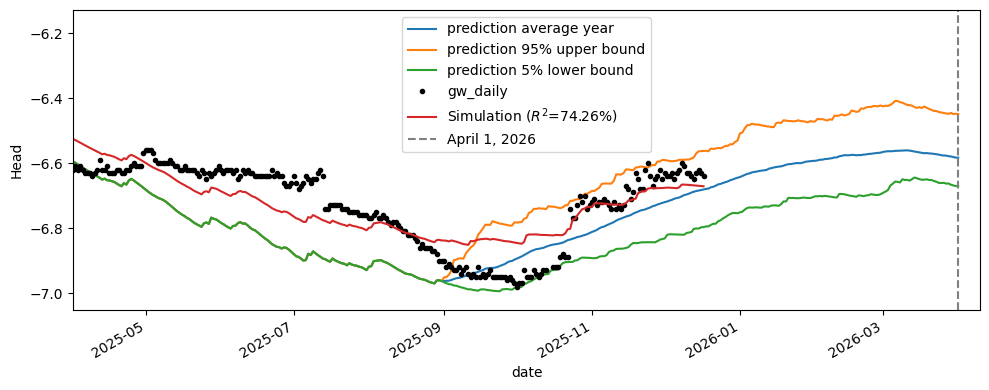

In [10]:
# Set up simulation model
ml_sim = ml.copy()

fig, ax = plt.subplots(figsize=(10, 4))

# ----------------------------
# Average scenario
# ----------------------------
# Assign the index for the forecast period
mean_surplus = mean_surplus[:212]  # only keep first 212 values
mean_surplus.index = pd.date_range("2025-09-01", "2026-03-31")

# Calculate stress before the forecast period (until 2025-08-31)
evaporation = pd.DataFrame(evaporation)
precipitation = pd.DataFrame(precipitation)
evap_factor = np.float64(evap_factor)

mean_stress_past = (
    precipitation["RH"][:"2025-08-31"].squeeze()
    + evap_factor * evaporation["EV24"][:"2025-08-31"].squeeze()
    )

mean_forecast = mean_surplus.diff().fillna(mean_surplus).squeeze()
mean_stress = pd.concat([mean_stress_past, mean_forecast])
# Force all datetimes in mean_stress to 00:00
mean_stress.index = pd.to_datetime(mean_stress.index).normalize()
# mean_stress = mean_stress_past.asfreq("D")

ml_sim.del_stressmodel("rainevap")
sm_sim = ps.StressModel(
    stress=mean_stress,  # <- adjust if needed
    rfunc=ps.Exponential(),
    name="rainevap",
    settings="prec",
)
ml_sim.add_stressmodel(sm_sim)
ml_sim.parameters.loc["rainevap_a", "optimal"] = ml.parameters.loc["rainevap_a", "optimal"]
ml_sim.parameters.loc["rainevap_A", "optimal"] = ml.parameters.loc["rainevap_A", "optimal"]

mean_sim = ml_sim.simulate(tmax="2026-04-01")
ax.plot(mean_sim, label="prediction average year")

# Upper bound
upper_bound = upper_bound[:212]  # only keep first 212 values
upper_bound.index = pd.date_range("2025-09-01", "2026-03-31")
upper_stress_past = (
    precipitation["RH"][:"2025-08-31"].squeeze()
    + evap_factor * evaporation["EV24"][:"2025-08-31"].squeeze()
    )
upper_forecast = upper_bound.diff().fillna(upper_bound).squeeze()
upper_stress = pd.concat([upper_stress_past, upper_forecast])
upper_stress.index = pd.to_datetime(mean_stress.index).normalize()

ml_sim.del_stressmodel("rainevap")
sm_sim = ps.StressModel(
    stress=upper_stress,  # <- adjust if needed
    rfunc=ps.Exponential(),
    name="rainevap",
    settings="prec",
)
ml_sim.add_stressmodel(sm_sim)
ml_sim.parameters.loc["rainevap_a", "optimal"] = ml.parameters.loc["rainevap_a", "optimal"]
ml_sim.parameters.loc["rainevap_A", "optimal"] = ml.parameters.loc["rainevap_A", "optimal"]

upper_sim = ml_sim.simulate(tmax="2026-04-01")
ax.plot(upper_sim, label="prediction 95% upper bound")

# Lower bound
lower_bound = lower_bound[:212]  # only keep first 212 values
lower_bound.index = pd.date_range("2025-09-01", "2026-03-31")
lower_stress_past = (
    precipitation["RH"][:"2025-08-31"].squeeze()
    + evap_factor * evaporation["EV24"][:"2025-08-31"].squeeze()
    )

lower_forecast = lower_bound.diff().fillna(lower_bound).squeeze()
lower_stress = pd.concat([lower_stress_past, lower_forecast])
lower_stress.index = pd.to_datetime(mean_stress.index).normalize()

ml_sim.del_stressmodel("rainevap")
sm_sim = ps.StressModel(
    stress=lower_stress,  # <- adjust if needed
    rfunc=ps.Exponential(),
    name="rainevap",
    settings="prec",
)
ml_sim.add_stressmodel(sm_sim)
ml_sim.parameters.loc["rainevap_a", "optimal"] = ml.parameters.loc["rainevap_a", "optimal"]
ml_sim.parameters.loc["rainevap_A", "optimal"] = ml.parameters.loc["rainevap_A", "optimal"]

lower_sim = ml_sim.simulate(tmax="2026-04-01")
ax.plot(lower_sim, label="prediction 5% lower bound")

ml.plot(ax=ax)
ax.axvline("2026-04-01", color="gray", ls="--", label="April 1, 2026")
ax.legend()
_ = ax.set_xlim(xmin=pd.Timestamp("2025-04-01"), xmax=pd.Timestamp("2026-04-10"))

In [14]:
# One file – most compact
pd.DataFrame({
    "Mean": mean_sim["2025-09-01":],
    "Upper": upper_sim["2025-09-01":],
    "Lower": lower_sim["2025-09-01":]
}).to_csv("three_scenarios_forecast.csv")